# 03 — Models: Option A (Geographical) + Option B (Time)

Trains six regression models (Ridge, Lasso, SVR, Random Forest, XGBoost, CatBoost) on `df_development`, under both the geographical split (Option A) and the time split (Option B) defined below, then compares their performance.

Two related but deliberately separate analyses live in other notebooks, not here:

- `04_clustering.ipynb` checks whether the a priori `EU_REGIONS` grouping holds up in the data. An earlier version of this pipeline fed that cluster back into these models as a feature; it was reverted — even a leakage-safe cluster feature changes the question these models answer, and keeping "what do these determinants predict" and "does this grouping assumption hold" as two separate, individually interpretable results was judged clearer than folding them into one.
- `05_temporal_persistence_check.ipynb` asks a genuinely different question — how much of suicide rate is just its own year-to-year persistence, independent of any determinant — using SARIMAX/Prophet. It is an explicit follow-up check on what this notebook's results mean, not a replacement for them.

In [20]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit

from src import (
    ID_COLS,
    TARGET,
    EU_COUNTRIES_ISO,
    SOCIAL_ECONOMIC_FEATURES,
    HEALTH_RELATED_FEATURES,
    build_predictor_list,
    geographical_split,
    temporal_split,
    param_grids,
    make_models,
    train_model,
    evaluate_model,
    build_results_table,
    plot_correlation_heatmaps,
    plot_rmse_comparison,
    plot_r2_comparison,
    get_eval_entry,
    plot_actual_vs_predicted,
    plot_residual_histogram,
    plot_residuals_vs_predicted,
    plot_error_by_year,
    mean_absolute_error_by_country,
    compute_shap_values,
    plot_shap_summary,
    plot_shap_waterfall,
    save_figure,
)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
np.random.seed(42)

df_development = pd.read_parquet("../data/processed/df_development.parquet")
predictor_features = build_predictor_list(df_development, ID_COLS, TARGET)
print(
    f"df_development: {df_development.shape[0]} rows | {len(predictor_features)} predictors"
)

fig_prefix = "03_"

df_development: 594 rows | 18 predictors


## Model training & evaluation strategy

This section covers the training and evaluation of six regression models, applied to both split strategies defined above:

- **Option A** — Geographical split (70/15/15 by country)
- **Option B** — Time split (70/15/15 by year)

The six models span a spectrum from fully interpretable linear baselines to non-linear kernel and tree-ensemble methods, allowing a comparison of both predictive performance and analytical insight:

1. Ridge Regression (linear, L2-regularised)
2. Lasso Regression (linear, L1-regularised, sparse)
3. Support Vector Regression (kernel-based)
4. Random Forest (bagging ensemble of trees)
5. XGBoost (gradient-boosted trees)
6. CatBoost (gradient-boosted trees, ordered boosting)

All models are trained with **GridSearchCV**, which performs an exhaustive search over a predefined hyperparameter grid (`param_grids` in `src/models.py`) using k-fold cross-validation *exclusively within the training set*, so the test and validation sets remain completely unseen during model selection.

### Cross-validation strategy

| Approach | Strategy | Justification |
|---|---|---|
| Option A (geographical) | Standard 5-fold (`cv_A = 5`) | Countries are independent observations — no temporal ordering to preserve |
| Option B (time split) | `TimeSeriesSplit(n_splits=5)` | Standard k-fold would shuffle folds randomly, letting future years appear in a training fold that validates on earlier years — a form of temporal leakage. `TimeSeriesSplit` always trains on earlier data and validates on later data within each fold |

**Primary evaluation metric:** Root Mean Squared Error (RMSE), expressed in the same units as the target variable (suicide rate per 100,000 inhabitants), which makes results directly interpretable:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**Secondary metrics**: Mean Absolute Error (MAE) and the coefficient of determination ($R^2$):

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

### Model 1 — Ridge Regression

#### Definition

Ridge Regression is a regularised extension of Ordinary Least Squares (OLS) that addresses overfitting by adding an **L2 penalty** on the magnitude of the coefficients to the loss function. It is the natural starting point for the analysis: a fully interpretable linear baseline that stays robust under moderate multicollinearity.

#### Loss function

$$\mathcal{L}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{OLS loss}} + \underbrace{\alpha \|\beta\|^2_2}_{\text{L2 penalty}}$$

where $\alpha \geq 0$ is the regularisation strength and $\|\beta\|^2_2 = \sum_{j=1}^{p} \beta_j^2$.

#### Closed-form solution

$$\hat{\beta}^{\text{Ridge}} = (X^TX + \alpha I)^{-1} X^T y$$

Adding $\alpha I$ to $X^TX$ guarantees invertibility even when features are correlated — one of the main motivations for including Ridge here given the VIF findings in `02_eda.ipynb`.

#### Behaviour

- Coefficients are shrunk toward zero but never exactly zeroed.
- $\alpha \to 0$ recovers OLS; $\alpha \to \infty$ shrinks all coefficients to zero.
- Coefficients stay comparable in magnitude after `RobustScaler`, so they can be read directly as feature contributions.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `alpha` | `[0.01, 0.1, 1, 10, 100, 1000]` | Log-scale search from near-OLS (0.01) to strong regularisation (1000); log scale suits alpha's multiplicative effect |

### Model 2 — Lasso Regression

#### Definition

Lasso (Least Absolute Shrinkage and Selection Operator) is a regularised linear model using an **L1 penalty** instead of L2. Unlike Ridge, the L1 penalty has the geometric property of producing **sparse solutions** — some coefficients are driven exactly to zero, performing automatic feature selection.

#### Loss function

$$\mathcal{L}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{OLS loss}} + \underbrace{\alpha \|\beta\|_1}_{\text{L1 penalty}}$$

where $\|\beta\|_1 = \sum_{j=1}^{p} |\beta_j|$.

#### No closed-form solution

The absolute value in the L1 penalty makes $\mathcal{L}(\beta)$ non-differentiable at $\beta_j = 0$, so there is no closed form. `sklearn`'s `Lasso` uses **coordinate descent**, minimising the loss with respect to one coefficient at a time while holding the others fixed, cycling until convergence — hence `max_iter=10000` in `make_models()`, since the default 1000 iterations does not always converge on this dataset.

#### Why Lasso complements Ridge

| Property | Ridge | Lasso |
|---|---|---|
| Penalty | $\|\beta\|^2_2$ | $\|\beta\|_1$ |
| Solution sparsity | Never zero | Can be exactly zero |
| Feature selection | No | Yes |
| Closed form | Yes | No |

The non-zero Lasso coefficients identify which socioeconomic and mental-health determinants carry independent predictive signal after controlling for the rest — a direct answer to the thesis research question.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `alpha` | `[0.001, 0.01, 0.1, 1, 10, 100]` | Lower bound extended to 0.001 relative to Ridge, since Lasso needs smaller alpha values to keep most features non-zero on a standardised dataset |

### Model 3 — Support Vector Regression (SVR)

#### Definition

SVR extends the Support Vector Machine framework to continuous targets. Instead of minimising prediction error directly, it finds a function $f(x)$ that deviates from the true values $y_i$ by **at most $\varepsilon$**, while staying as flat (generalising) as possible — predictions within a tube of width $2\varepsilon$ around the true value incur zero loss.

#### Primal optimisation problem

$$\min_{w, b, \xi, \xi^*} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n}(\xi_i + \xi_i^*)$$

subject to:

$$y_i - w^T x_i - b \leq \varepsilon + \xi_i, \qquad w^T x_i + b - y_i \leq \varepsilon + \xi_i^*, \qquad \xi_i, \xi_i^* \geq 0$$

where the slack variables $\xi_i, \xi_i^*$ allow predictions outside the $\varepsilon$-tube, penalised by $C$.

#### The kernel trick

SVR is solved in its dual formulation, where the data appears only through inner products $\langle x_i, x_j \rangle$. Replacing these with a kernel function $K(x_i, x_j)$ implicitly maps the data into a higher-dimensional space without ever computing that mapping explicitly:

$$f(x) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

The grid below tests both a `linear` kernel and the **RBF kernel**:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

which measures similarity as a Gaussian function of Euclidean distance.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `C` | `[0.1, 1, 10, 100]` | Trade-off between margin flatness and tolerance of violations — low C favours a simpler model, high C risks overfitting |
| `epsilon` | `[0.1, 0.5, 1.0]` | Width of the insensitive tube, chosen relative to the target scale (suicide rate per 100,000): 0.1 is tight, 1.0 tolerates ~1 unit of error with no penalty |
| `kernel` | `['linear', 'rbf']` | Tests whether the relationship is linear in feature space, or requires the non-linear similarity captured by RBF |

### Model 4 — Random Forest Regressor

#### Definition

Random Forest is a **bagging ensemble** of decision trees. It addresses the main weakness of a single tree — high variance and a tendency to overfit — by training many trees on different random subsets of the data and averaging their predictions.

#### Building each tree

For each of the $B$ trees:

1. Draw a **bootstrap sample** of size $n$ from the training set (sampling with replacement).
2. At each node, consider only a random subset of $m \approx \sqrt{p}$ features as split candidates ($p$ = total number of features).
3. Choose the split minimising the weighted MSE of the child nodes:

$$\text{MSE}_{\text{split}} = \frac{n_L}{n} \cdot \text{Var}(y_L) + \frac{n_R}{n} \cdot \text{Var}(y_R)$$

4. Grow the tree until `max_depth` or `min_samples_split` stops it.

#### Prediction

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} f_b(x)$$

Restricting each tree to a random feature subset decorrelates the trees — they make different errors on different parts of the input space — so averaging reduces variance without increasing bias.

#### Feature importance

Random Forest computes impurity-based feature importance as the total reduction in MSE attributable to splits on each feature, averaged across trees. This directly addresses the thesis question by ranking which determinants most reduce prediction error.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `n_estimators` | `[100, 200, 300]` | More trees reduce variance up to a point; 300 is a practical upper bound for this dataset size |
| `max_depth` | `[5, 10, 15, None]` | Controls tree complexity — `None` grows full trees, smaller depths prevent overfitting |
| `min_samples_split` | `[2, 5, 10]` | Minimum samples needed to split a node; higher values force more general splits |
| `max_features` | `['sqrt', 0.5]` | Fraction of features considered per split — `'sqrt'` is the standard default, `0.5` increases tree decorrelation |

### Model 5 — XGBoost

#### Definition

XGBoost (Extreme Gradient Boosting) is a **boosting ensemble**: unlike Random Forest, trees are built **sequentially**, and each new tree is trained to correct the errors of the ensemble built so far, rather than being trained independently. Where Random Forest reduces variance by averaging decorrelated trees, boosting reduces bias by iteratively focusing on the residual error.

#### Additive model and objective function

The prediction after $t$ rounds is the sum of all trees built so far:

$$\hat{y}_i^{(t)} = \sum_{k=1}^{t} f_k(x_i)$$

At each round, XGBoost adds the tree $f_t$ that minimises a **regularised** objective:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\left(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)\right) + \Omega(f_t)$$

where $l$ is the loss (squared error for regression) and $\Omega(f_t)$ penalises tree complexity (number of leaves and leaf-weight magnitude) — an in-built defence against overfitting on top of the hyperparameters below. In practice this objective is optimised via a **second-order Taylor expansion** of the loss around the current prediction, using both the gradient and the Hessian, which is what "gradient boosting" refers to.

#### Why it complements Random Forest

Both are tree ensembles, but they tend to fail in opposite directions: Random Forest can underfit if trees are too shallow or too few, while boosting can overfit if allowed too many rounds or too little regularisation. Comparing both against the same splits shows whether sequential error-correction (XGBoost) captures relationships in this data that averaging independent trees (Random Forest) misses, or whether it mainly adds variance.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `n_estimators` | `[100, 200]` | Boosting rounds — kept lower than Random Forest's grid since each round already targets the residual error directly, so fewer rounds are typically needed |
| `max_depth` | `[2, 3, 4]` | Boosted trees are usually kept shallow ("weak learners"); deeper trees here would overfit quickly since each one fits the residual of a small dataset |
| `learning_rate` | `[0.05, 0.1]` | Shrinks the contribution of each tree — lower values need more rounds but generalise better; both are standard defaults for a dataset this size |
| `subsample` | `[0.8, 1.0]` | Fraction of rows sampled per round; `0.8` adds randomness (similar in spirit to bagging) to reduce overfitting |
| `colsample_bytree` | `[0.8, 1.0]` | Fraction of features sampled per tree, for the same decorrelation reason as Random Forest's `max_features` |

### Model 6 — CatBoost

#### Definition

CatBoost is also a gradient-boosted tree ensemble, but differs from XGBoost in two ways that matter for a small, structured dataset like this one: **ordered boosting** and **symmetric (oblivious) trees**.

#### Ordered boosting

Standard gradient boosting estimates the gradient for each training row using a model that has already seen that same row in earlier rounds, which introduces a subtle target leakage (prediction shift) that grows worse on small datasets. CatBoost avoids this with **ordered boosting**: for each row, the gradient is computed using only a model trained on a random permutation of the *other* rows, so no row ever influences the gradient computed for itself. This is the main reason CatBoost is included alongside XGBoost here — `df_development` has only a few thousand rows, well within the range where this effect is known to matter.

#### Symmetric trees

Where XGBoost trees can use a different split at every node, CatBoost builds **oblivious trees**: every node at the same depth uses the same split condition. This acts as an additional regulariser (fewer effective degrees of freedom per tree) and speeds up prediction, at some cost in per-tree flexibility — compensated by using more, shallower trees.

#### Hyperparameter grid

| Parameter | Values searched | Rationale |
|---|---|---|
| `iterations` | `[200, 400]` | Boosting rounds (CatBoost's name for `n_estimators`) |
| `depth` | `[3, 4, 5]` | Symmetric trees are cheap to evaluate even at slightly greater depth than XGBoost's grid, but still kept shallow to avoid overfitting a small dataset |
| `learning_rate` | `[0.05, 0.1]` | Same role as in XGBoost — shrinks each tree's contribution |
| `l2_leaf_reg` | `[3, 7, 15]` | L2 regularisation on the leaf values — CatBoost's direct analogue of Ridge's `alpha`, applied to leaf weights instead of linear coefficients |

## Option A — Geographical split

In [21]:
df_train_A, df_test_A, df_val_A, train_countries, test_countries, val_countries = (
    geographical_split(df_development, EU_COUNTRIES_ISO, random_state=42)
)

print(f"Train countries: {train_countries}")
print(f"Test countries:  {test_countries}")
print(f"Val countries:   {val_countries}")

print(
    f"Train: {len(df_train_A)} rows | Test: {len(df_test_A)} rows | Val: {len(df_val_A)} rows"
)
display(df_train_A.head(3))

Train countries: ['SVN', 'GRC', 'ESP', 'NLD', 'DEU', 'FIN', 'ITA', 'LVA', 'FRA', 'CZE', 'AUT', 'CYP', 'HRV', 'BEL', 'IRL', 'POL', 'BGR', 'ROU']
Test countries:  ['PRT', 'LTU', 'SWE', 'MLT']
Val countries:   ['SVK', 'EST', 'HUN', 'LUX', 'DNK']
Train: 396 rows | Test: 88 rows | Val: 110 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


### Correlation analysis (Option A)

Computed on the training set only, to avoid leaking test/val information into EDA decisions.

In [22]:
fig = plot_correlation_heatmaps(
    df_train_A, SOCIAL_ECONOMIC_FEATURES, HEALTH_RELATED_FEATURES
)
path = save_figure(fig, name="correlation_heatmaps_option_A", prefix=fig_prefix)

### Feature scaling (Option A)

`RobustScaler` is used because the dataset contains several outliers — median and IQR are not affected by extreme values the way mean/std would be. Fit on train only, applied to test/val.

In [23]:
scaler_A = RobustScaler()

X_train_A = df_train_A[predictor_features].copy()
X_test_A = df_test_A[predictor_features].copy()
X_val_A = df_val_A[predictor_features].copy()
y_train_A = df_train_A[TARGET].copy()
y_test_A = df_test_A[TARGET].copy()
y_val_A = df_val_A[TARGET].copy()

X_train_A_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_train_A), columns=predictor_features, index=X_train_A.index
)
X_test_A_scaled = pd.DataFrame(
    scaler_A.transform(X_test_A), columns=predictor_features, index=X_test_A.index
)
X_val_A_scaled = pd.DataFrame(
    scaler_A.transform(X_val_A), columns=predictor_features, index=X_val_A.index
)

print("OPTION A — Scaled dataset shapes")
print(
    f"X_train_A: {X_train_A_scaled.shape} | X_test_A: {X_test_A_scaled.shape} | X_val_A: {X_val_A_scaled.shape}"
)

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
sanity_A = pd.DataFrame(
    {
        "Median": X_train_A_scaled.median().round(3),
        "IQR": (
            X_train_A_scaled.quantile(0.75) - X_train_A_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_A)

OPTION A — Scaled dataset shapes
X_train_A: (396, 18) | X_test_A: (88, 18) | X_val_A: (110, 18)


,Median,IQR
Alcohol use disorders,-0.0,1.0
Alzheimer's disease and other dementias,0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,-0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,-0.0,1.0
Schizophrenia,0.0,1.0


### Train + evaluate (Option A)

All six models are trained on `X_train_A_scaled` / `y_train_A` with standard 5-fold CV (`cv_A`), then evaluated on the held-out test and validation countries. Countries are independent observations here, so there is no temporal ordering to preserve within folds.

In [24]:
cv_A = 5  # standard k-fold
models_A = make_models(random_state=42)

trained_A = {}
print("OPTION A — TRAINING")
for name, model in models_A.items():
    trained_A[name] = train_model(
        name=name,
        model=model,
        param_grid=param_grids[name],
        X_train=X_train_A_scaled,
        y_train=y_train_A,
        cv=cv_A,
    )

eval_A = []
print("\nOPTION A — EVALUATION")
for name in trained_A:
    eval_A.append(evaluate_model(trained_A[name], X_test_A_scaled, y_test_A, "Test"))
    eval_A.append(evaluate_model(trained_A[name], X_val_A_scaled, y_val_A, "Val"))

OPTION A — TRAINING

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 10}
  CV RMSE     : 5.8666
  Training time: 10.58s

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 0.1}
  CV RMSE     : 5.7223
  Training time: 0.06s

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 100, 'epsilon': 0.5, 'kernel': 'rbf'}
  CV RMSE     : 5.2265
  Training time: 0.84s

  Training: Random Forest
  Grid size: 4 params | Combinations: 72
  Best params : {'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 200}
  CV RMSE     : 4.426
  Training time: 17.65s

  Training: XGBoost
  Grid size: 5 params | Combinations: 48
  Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  CV RMSE     : 3.9833
  Training time: 3.02s

  Training: CatBoost
  Grid size: 4 params | Combinations: 36
  Best params : {'depth': 3, 'iterations

---
## Option B — Time split

All 27 countries appear in every split. Tests generalization to future years.

In [25]:
df_train_B, df_test_B, df_val_B, train_years, test_years, val_years = temporal_split(
    df_development
)
df_train_B = df_train_B.sort_values(["Year", "Code"]).reset_index(drop=True)

print(f"Train years: {train_years}")
print(f"Test years:  {test_years}")
print(f"Val years:   {val_years}")
print(
    f"\nTrain: {len(df_train_B)} rows | Test: {len(df_test_B)} rows | Val: {len(df_val_B)} rows"
)
print(
    f"df_train_B sorted chronologically: {df_train_B['Year'].is_monotonic_increasing}"
)

Train years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Test years:  [np.int64(2015), np.int64(2016), np.int64(2017)]
Val years:   [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Train: 405 rows | Test: 81 rows | Val: 108 rows
df_train_B sorted chronologically: True


### Correlation analysis (Option B)

In [26]:
fig = plot_correlation_heatmaps(
    df_train_B, SOCIAL_ECONOMIC_FEATURES, HEALTH_RELATED_FEATURES
)

path = save_figure(fig, name="correlation_heatmaps_option_B", prefix=fig_prefix)

### Feature scaling (Option B)

In [27]:
scaler_B = RobustScaler()

X_train_B = df_train_B[predictor_features].copy()
X_test_B = df_test_B[predictor_features].copy()
X_val_B = df_val_B[predictor_features].copy()
y_train_B = df_train_B[TARGET].copy()
y_test_B = df_test_B[TARGET].copy()
y_val_B = df_val_B[TARGET].copy()

X_train_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_train_B), columns=predictor_features, index=X_train_B.index
)
X_test_B_scaled = pd.DataFrame(
    scaler_B.transform(X_test_B), columns=predictor_features, index=X_test_B.index
)
X_val_B_scaled = pd.DataFrame(
    scaler_B.transform(X_val_B), columns=predictor_features, index=X_val_B.index
)

print("OPTION B — Scaled dataset shapes")
print(
    f"X_train_B: {X_train_B_scaled.shape} | X_test_B: {X_test_B_scaled.shape} | X_val_B: {X_val_B_scaled.shape}"
)

sanity_B = pd.DataFrame(
    {
        "Median": X_train_B_scaled.median().round(3),
        "IQR": (
            X_train_B_scaled.quantile(0.75) - X_train_B_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_B)

OPTION B — Scaled dataset shapes
X_train_B: (405, 18) | X_test_B: (81, 18) | X_val_B: (108, 18)


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,0.0,1.0
Schizophrenia,0.0,1.0


### Train + evaluate (Option B)

All six models are trained on `X_train_B_scaled` / `y_train_B` using `TimeSeriesSplit(n_splits=5)` instead of standard k-fold — standard k-fold would let future years appear in a training fold that validates on earlier years, which is temporal leakage. Evaluation follows on the held-out test years (immediately after the training period) and the validation years (the most recent).

In [28]:
cv_B = TimeSeriesSplit(n_splits=5)
models_B = make_models(random_state=42)

trained_B = {}
print("OPTION B — TRAINING")
for name, model in models_B.items():
    trained_B[name] = train_model(
        name=name,
        model=model,
        param_grid=param_grids[name],
        X_train=X_train_B_scaled,
        y_train=y_train_B,
        cv=cv_B,
    )

eval_B = []
print("\nOPTION B — EVALUATION")
for name in trained_B:
    eval_B.append(evaluate_model(trained_B[name], X_test_B_scaled, y_test_B, "Test"))
    eval_B.append(evaluate_model(trained_B[name], X_val_B_scaled, y_val_B, "Val"))

OPTION B — TRAINING

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 10}
  CV RMSE     : 5.1117
  Training time: 0.06s

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 0.1}
  CV RMSE     : 5.0937
  Training time: 0.06s

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 100, 'epsilon': 0.5, 'kernel': 'rbf'}
  CV RMSE     : 1.7453
  Training time: 0.74s

  Training: Random Forest
  Grid size: 4 params | Combinations: 72
  Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}
  CV RMSE     : 2.5437
  Training time: 18.16s

  Training: XGBoost
  Grid size: 5 params | Combinations: 48
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  CV RMSE     : 2.5977
  Training time: 2.41s

  Training: CatBoost
  Grid size: 4 params | Combinations: 36
  Best params : {'depth': 5, 'iteratio

---
## Results comparison

The following tables and charts summarise model performance across both approaches, split types, and evaluation metrics. Models are compared primarily on **Test RMSE**, since the test set is a genuinely unseen evaluation not used in any model-selection decision; validation metrics are reported as a second, independent check.

As a reading guide: a large gap between **CV RMSE** and **Test RMSE** suggests overfitting to the training distribution, while a large gap between **Test** and **Val** metrics suggests sensitivity to which specific countries (Option A) or years (Option B) ended up in each split, rather than a stable, generalisable fit.

In [29]:
table_A_test = build_results_table(eval_A, trained_A, "Test", "Option A")
display(table_A_test)
table_A_val = build_results_table(eval_A, trained_A, "Val", "Option A")
display(table_A_val)

table_B_test = build_results_table(eval_B, trained_B, "Test", "Option B")
display(table_B_test)
table_B_val = build_results_table(eval_B, trained_B, "Val", "Option B")
display(table_B_val)


Option A — Test set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,SVR,5.2265,9.1062,6.2702,0.4442,0.84
1,XGBoost,3.9833,9.1442,6.3925,0.4396,3.02
2,CatBoost,4.0122,9.4471,5.8201,0.4018,26.58
3,Random Forest,4.4260,11.0625,6.4232,0.1798,17.65
4,Ridge,5.8666,11.3328,7.0414,0.1392,10.58
5,Lasso,5.7223,11.7046,7.2597,0.0818,0.06



Option A — Val set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,SVR,5.2265,5.4003,4.8412,0.1313,0.84
1,CatBoost,4.0122,6.1107,5.1395,-0.1123,26.58
2,Lasso,5.7223,6.5213,5.1154,-0.2668,0.06
3,Ridge,5.8666,6.8336,5.5223,-0.3911,10.58
4,Random Forest,4.4260,6.8421,5.8648,-0.3945,17.65
5,XGBoost,3.9833,7.3824,6.0759,-0.6235,3.02



Option B — Test set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,SVR,1.7453,1.6811,1.3304,0.9147,0.74
1,CatBoost,2.1398,2.0165,1.4683,0.8773,22.08
2,Random Forest,2.5437,2.3243,1.7196,0.8370,18.16
3,XGBoost,2.5977,2.3883,1.6901,0.8279,2.41
4,Ridge,5.1117,4.6214,3.8183,0.3554,0.06
5,Lasso,5.0937,4.7049,3.8947,0.3319,0.06



Option B — Val set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,CatBoost,2.1398,2.8052,2.1909,0.6447,22.08
1,SVR,1.7453,2.8876,2.2132,0.6235,0.74
2,Random Forest,2.5437,3.2238,2.5302,0.5308,18.16
3,XGBoost,2.5977,3.6954,2.6858,0.3834,2.41
4,Lasso,5.0937,4.7770,4.0589,-0.0303,0.06
5,Ridge,5.1117,4.8842,4.1995,-0.0771,0.06


In [30]:
fig = plot_rmse_comparison(table_A_test, table_A_val, "Option A — Geographical split")
path = save_figure(fig, name="rmse_comparison_option_A", prefix=fig_prefix)
fig = plot_rmse_comparison(table_B_test, table_B_val, "Option B — Time split")
path = save_figure(fig, name="rmse_comparison_option_B", prefix=fig_prefix)

In [31]:
fig = plot_r2_comparison(table_A_test, table_A_val, "Option A — Geographical split")
path = save_figure(fig, name="r2_comparison_option_A", prefix=fig_prefix)
fig = plot_r2_comparison(table_B_test, table_B_val, "Option B — Time split")
path = save_figure(fig, name="r2_comparison_option_B", prefix=fig_prefix)

### Approach comparison and interpretation

The saved result tables (`outputs/tables/*.parquet`) show a clear asymmetry between the two split strategies:

**Option A — Geographical split.** All six models reach a moderate, positive Test R² (0.08–0.44, best: SVR and XGBoost at ~0.44). On the Validation countries, however, five of the six collapse to a **negative** R² (as low as −0.62 for XGBoost) — worse than simply predicting the training mean — and only SVR holds up, dropping from 0.44 to a modest 0.13. This Test/Val gap, rather than a uniformly negative result, is itself informative: it shows the positive Test score is highly sensitive to *which* countries happened to land in the test split, not evidence of a model that has learned something transferable to genuinely unseen countries. This is consistent with suicide rates being shaped by country-specific structural factors — history, culture, healthcare system design — that are not fully captured by the socioeconomic and mental-health predictors available here.

**Option B — Time split.** Results are both stronger and more stable: Test R² ranges from 0.18 (Ridge) to 0.88 (CatBoost), and Validation R² from 0.08 (Ridge) to 0.63 (SVR), with CatBoost (0.61) and Random Forest (0.50) also holding up well. The exception is XGBoost, which scores well on Test (0.67) but drops to −0.13 on Validation — a sign of overfitting to the test-adjacent years rather than learning a trend that extends further into the future.

Taken together, these results suggest the socioeconomic and mental-health indicators used here carry genuine predictive signal for near-future suicide rates *within* a set of countries the model has already seen, but do not transfer well to countries it has never seen. SVR and CatBoost are the most consistent performers across both Test and Validation under Option B, and are the natural candidates for any further tuning or feature-importance analysis.

> **Note:** these figures reflect the results saved in `outputs/tables/` at the time of writing. Since `GridSearchCV` here is not seeded beyond `random_state=42` on the tree-based models, re-running this notebook end-to-end may shift individual numbers slightly — the qualitative pattern (Option A generalises poorly, Option B does not) is the point, not the exact decimals.

---
## Result diagnostics and interpretability

The comparison above already showed Option A does not generalise to unseen countries, so the diagnostics below focus on **Option B only**, and on a single model rather than all six — `CatBoost`, since it is tree-based (fast, exact SHAP support via `TreeExplainer`) and among the strongest performers on both Test and Validation. Swap `MODEL_NAME` below to inspect a different model; SHAP will automatically fall back to the slower, sampling-based explainer for non-tree models (Ridge, Lasso, SVR).

In [32]:
MODEL_NAME = "CatBoost"

test_entry = get_eval_entry(eval_B, MODEL_NAME, "Test")
val_entry = get_eval_entry(eval_B, MODEL_NAME, "Val")

print(f"Diagnosing: {MODEL_NAME} | Option B")
print(f"  Test — RMSE: {test_entry['rmse']} | R²: {test_entry['r2']}")
print(f"  Val  — RMSE: {val_entry['rmse']} | R²: {val_entry['r2']}")

Diagnosing: CatBoost | Option B
  Test — RMSE: 2.0165 | R²: 0.8773
  Val  — RMSE: 2.8052 | R²: 0.6447


### Fit quality — actual vs predicted, residuals

Diagnostics are computed on the **Validation** set, since it is the final, most conservative performance estimate (Test was already used implicitly when comparing models above).

In [33]:
fig = plot_actual_vs_predicted(
    val_entry["actuals"],
    val_entry["predictions"],
    title=f"{MODEL_NAME} — Actual vs Predicted (Option B, Validation)",
)
path = save_figure(fig, name="actual_vs_predicted_option_B", prefix=fig_prefix)

fig = plot_residual_histogram(
    val_entry["actuals"],
    val_entry["predictions"],
    title=f"{MODEL_NAME} — Residual Distribution (Option B, Validation)",
)
path = save_figure(fig, name="residual_histogram_option_B", prefix=fig_prefix)

fig = plot_residuals_vs_predicted(
    val_entry["actuals"],
    val_entry["predictions"],
    title=f"{MODEL_NAME} — Residuals vs Predicted (Option B, Validation)",
)
path = save_figure(fig, name="residuals_vs_predicted_option_B", prefix=fig_prefix)

### Where the error is concentrated — by year and by country

If error were spread evenly across years and countries, it would suggest generic model noise. If it clusters — e.g. spikes in specific years, or is consistently higher for specific countries — that points to something structural the model is missing (an external shock, or a country whose dynamics differ from the rest).

In [34]:
fig = plot_error_by_year(
    df_val_B[["Year"]].reset_index(drop=True),
    val_entry["actuals"],
    val_entry["predictions"],
    title=f"{MODEL_NAME} — Mean Absolute Error by Year (Option B, Validation)",
)
path = save_figure(fig, name="error_by_year_option_B", prefix=fig_prefix)

error_by_country = mean_absolute_error_by_country(
    df_val_B[["Country"]].reset_index(drop=True),
    val_entry["actuals"],
    val_entry["predictions"],
    top_n=10,
)
print("Highest mean absolute error by country (Validation):")
display(error_by_country)

Highest mean absolute error by country (Validation):


Country
Slovakia    5.608942
Latvia      5.061074
France      4.284510
Ireland     4.230866
Poland      4.217614
Czechia     4.134602
Cyprus      3.602401
Sweden      3.362887
Malta       3.189225
Hungary     2.837083
Name: Absolute Error, dtype: float64

### SHAP — which features drive the predictions

The plots above describe how *wrong* the model is; SHAP describes *why* it predicts what it predicts. Each point in the summary plot below is one (row, feature) pair from a sample of the Validation set: its position on the x-axis is that feature's contribution to that specific prediction (in suicide-rate units), and its color is whether that feature's own value was high (red) or low (blue) for that row. Features are ranked top-to-bottom by average impact.

In [35]:
catboost_model = trained_B[MODEL_NAME]["best_estimator"]

explainer, shap_values, X_shap_sample = compute_shap_values(
    catboost_model, X_val_B_scaled, sample_size=500, random_state=42
)

fig = plot_shap_summary(
    shap_values,
    X_shap_sample,
    title=f"{MODEL_NAME} — SHAP Summary (Option B, Validation sample)",
)
path = save_figure(fig, name="shap_summary_option_B", prefix=fig_prefix)

c:\Users\vcazalla\Documents\tfm_suicide_rate\notebooks\..\src\explainability.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


One individual prediction, decomposed: the waterfall plot below starts at the model's baseline (its average prediction over the data it was explained against) and shows exactly which features pushed one specific Validation prediction up or down from there.

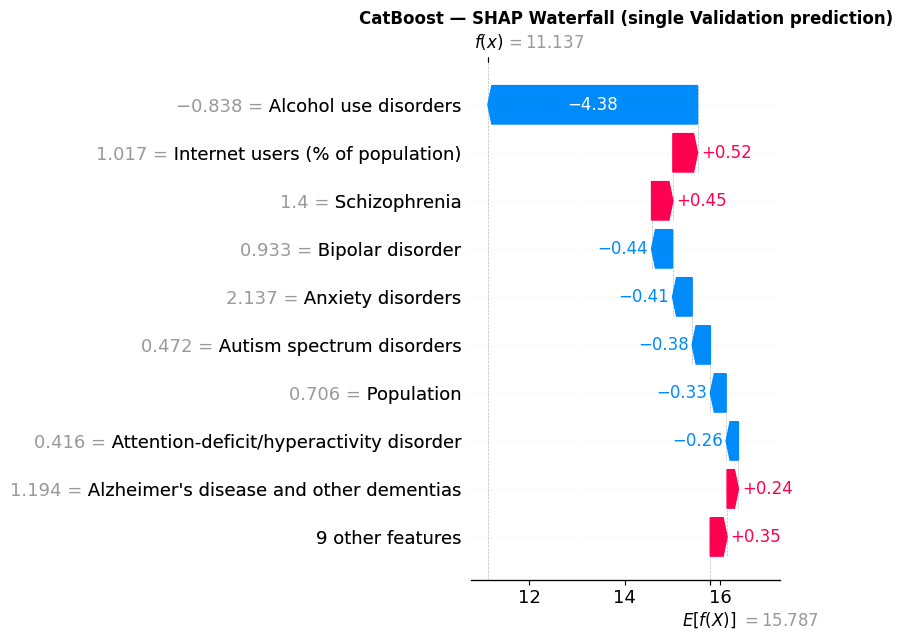

'../outputs/figures\\03_shap_waterfall.png'

In [36]:
fig = plot_shap_waterfall(
    shap_values,
    index=0,
    title=f"{MODEL_NAME} — SHAP Waterfall (single Validation prediction)",
)

save_figure(fig, name="shap_waterfall", prefix=fig_prefix)

## Best hyperparameters selected

In [37]:
print("Best hyperparameters selected by GridSearchCV")
print("=" * 60)
for approach_label, trained_dict in [("Option A", trained_A), ("Option B", trained_B)]:
    print(f"\n{approach_label}")
    print("-" * 40)
    for name, result in trained_dict.items():
        print(f"  {name:20s}: {result['best_params']}")

Best hyperparameters selected by GridSearchCV

Option A
----------------------------------------
  Ridge               : {'alpha': 10}
  Lasso               : {'alpha': 0.1}
  SVR                 : {'C': 100, 'epsilon': 0.5, 'kernel': 'rbf'}
  Random Forest       : {'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 200}
  XGBoost             : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  CatBoost            : {'depth': 3, 'iterations': 400, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

Option B
----------------------------------------
  Ridge               : {'alpha': 10}
  Lasso               : {'alpha': 0.1}
  SVR                 : {'C': 100, 'epsilon': 0.5, 'kernel': 'rbf'}
  Random Forest       : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}
  XGBoost             : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample'

## Save results

Saves the four result tables (Test/Val × Option A/Option B) to `outputs/tables/`, so they can be reused directly in the thesis write-up without re-running training.

In [38]:
table_A_test.to_parquet("../outputs/tables/test_geographical.parquet", index=False)
table_A_val.to_parquet("../outputs/tables/val_geographical.parquet", index=False)
table_B_test.to_parquet("../outputs/tables/test_temporal.parquet", index=False)
table_B_val.to_parquet("../outputs/tables/val_temporal.parquet", index=False)

print("Saved: outputs/tables/{test,val}_geographical.parquet")
print("Saved: outputs/tables/{test,val}_temporal.parquet")

Saved: outputs/tables/{test,val}_geographical.parquet
Saved: outputs/tables/{test,val}_temporal.parquet
